In [ ]:
# Years to report on
comparison_year = ""
year_of_interest = ""

# Location to report on
location = ""

# Category to report on
category = ""

# Species to report on
species = ""

# Export format for the chart:
# PNG     - export as PNG image
# PDF     - export as PDF file
# <blank> - do not export
export_format = "PNG"

In [86]:
%run pathutils.ipynb
%run database.ipynb
%run export.ipynb

In [87]:
def load_data(year, location, category, species):
    # Construct the query
    query = construct_query("year_to_year_comparison.sql", {
        "YEAR": year,
        "LOCATION": location,
        "CATEGORY": category,
        "SPECIES": species
    })

    # Connect to the database and execute the query and read the results into a dataframe
    df = query_data(query)

    # Check there is some data
    if not df.shape[0]:
        message = f"No data found for species '{species}', category '{category}' at location '{location}' durng '{year}'"
        raise ValueError(message)

    # Index sightings by month and label the series with its year
    df = df.assign(Month=df["Month"].astype(str).str.zfill(2)).set_index("Month")["Sightings"].rename(str(year))
    return df

In [88]:
import pandas as pd

# Load the data for the two years
comparison_df = load_data(comparison_year, location, category, species)
year_of_interest_df = load_data(year_of_interest, location, category, species)

combined_df = pd.concat([comparison_df, year_of_interest_df],axis=1).reindex([f"{month:02d}" for month in range(1, 13)])
display(combined_df)

,2025,2026
Month,,
01,29,31.0
02,27,25.0
03,29,26.0
04,29,27.0
05,25,26.0
06,18,18.0
07,31,31.0
08,14,26.0
09,25,16.0


In [89]:
# Create the folder to hold exported reports
export_folder_path = get_export_folder_path()

# Construct the export file name
clean_location = clean_string(location)
clean_category = clean_string(category)
clean_species = clean_string(species)

export_file_name = f"{comparison_year}-{year_of_interest}-{clean_location}"
if clean_category:
    export_file_name += f"-{clean_category}"
if clean_species:
    export_file_name += f"-{clean_species}"

export_to_spreadsheet(export_folder_path, f"{export_file_name}.xlsx", {
    "Comparison": combined_df
})

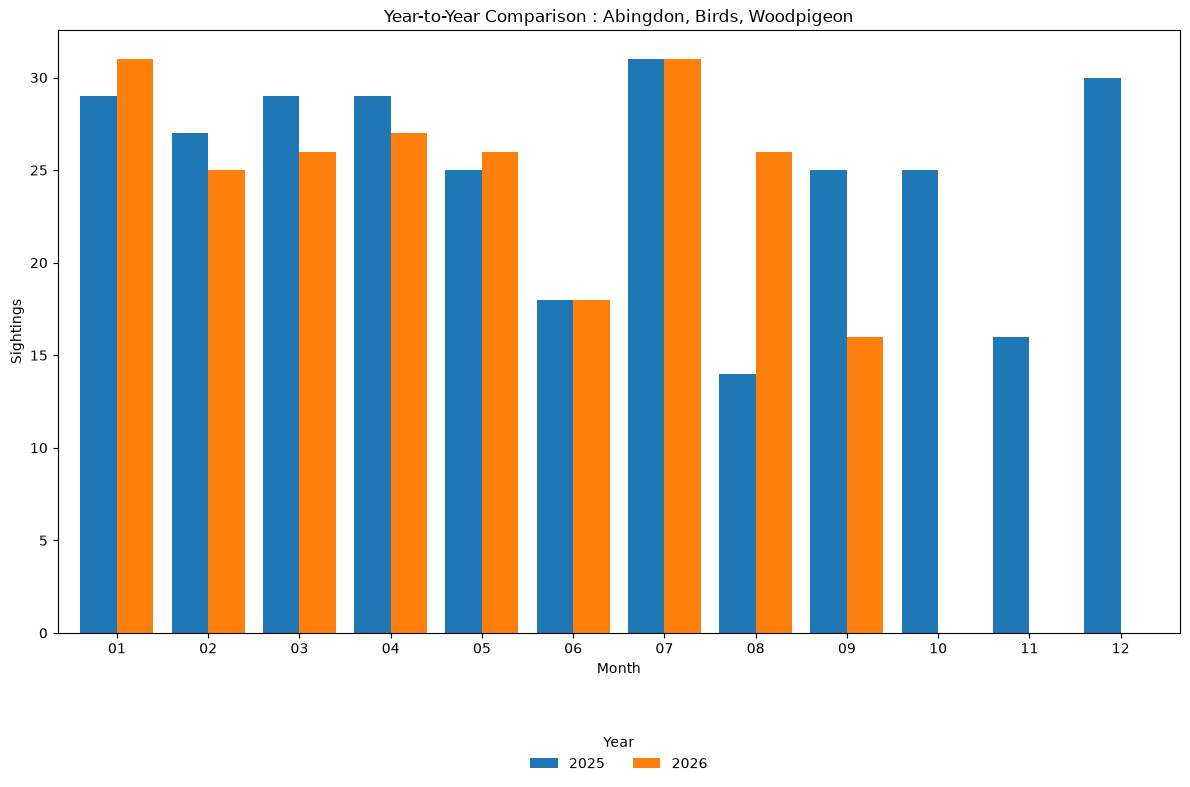

In [90]:
import matplotlib.pyplot as plt

ax = combined_df.plot.bar(
    figsize=(12, 8),
    width=0.8,
    rot=0,  # Keep month labels horizontal
)

ax.set_xlabel("Month")
ax.set_ylabel("Sightings")

title = f"Year-to-Year Comparison : {location}"
if species:
    title += f", {category}"
if species:
    title += f", {species}"
ax.set_title(title)

# Place the legend underneath the chart
ax.legend(
    title="Year",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
)

plt.tight_layout()

# Export the chart
export_chart(export_folder_path, export_file_name, export_format)

plt.show()